In [ ]:
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = ""

llm = init_chat_model("gpt-5.2")

In [6]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field


In [7]:
## Document Load
loader = PyPDFLoader("sample.pdf")
docs = loader.load()

## split - Chunks
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
docs = splitter.split_documents(docs)

## embeddings and Vector DB
embed = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)

In [ ]:
#llm = ChatGroq(model="openai/gpt-oss-20b")

In [8]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents : list = []
    context : str = Field(description="Context Data for user question", default="")
    answer : str = Field(description="Final Answer...", default="")


In [9]:
# question -> retrieve -> context -> generate -> end

def retrieve_node(state:RagState) -> RagState:
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs
    return state


def create_context_node(state:RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state


def generate_node(state:RagState) -> RagState:
    prompt = f"""
        You are a assistant and provide the answer for user question based on the provided context.
        If you don't find the relevant answer, then just say 'I dont know.'.
        Context is: {state.context},
        Questions is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state
    

In [10]:
graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, 'retrieve_node')
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

graph = graph.compile()

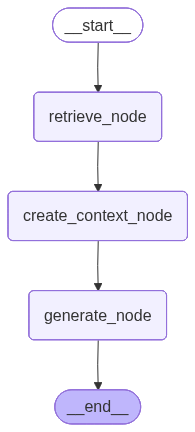

In [20]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

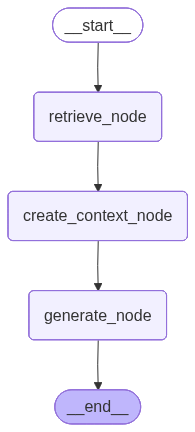

In [11]:
graph

In [14]:
res = graph.invoke({"question":"What baselines were used to compare Meta’s reward models, and how did GPT-4 perform relative to them?"})

In [15]:
print(res["answer"])

The baselines used were **SteamSHP-XL (FLAN-T5-xl)**, the **Open Assistant reward model (DeBERTa V3 Large)**, and **GPT-4** (queried via the OpenAI API with a zero-shot “choose the best answer between A and B” prompt).

**GPT-4 performed better than the other non-Meta reward model baselines**, even though it was not trained specifically for this reward modeling task, but **Meta’s own reward models performed best overall** on Meta’s internal test sets.


RANGGRAPH with CITATIONs

In [16]:
# ============================================================
# LANGGRAPH RAG WITH CITATIONS
# PDF Question Answering with Source References
# ============================================================

# pip install langgraph langchain langchain-openai
# pip install langchain-community pypdf python-dotenv

# ============================================================
# STEP 1: Imports
# ============================================================

from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from typing import List

from langgraph.graph import StateGraph, START, END

from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore

# ============================================================
# STEP 2: LLM
# ============================================================

llm = init_chat_model("gpt-5.2")

# ============================================================
# STEP 3: Load PDF
# ============================================================

loader = PyPDFLoader("sample.pdf")
docs = loader.load()

# ============================================================
# STEP 4: Chunking
# ============================================================

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = splitter.split_documents(docs)

# ============================================================
# STEP 5: Embeddings + Vector Store
# ============================================================

embed = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)

# ============================================================
# STEP 6: State
# ============================================================

class RagState(BaseModel):
    question: str
    documents: List = Field(default_factory=list)
    context: str = ""
    answer: str = ""

# ============================================================
# STEP 7: Retrieve Node
# ============================================================

def retrieve_node(state: RagState) -> RagState:

    docs = vector_store.similarity_search(
        query=state.question,
        k=4
    )

    state.documents = docs
    return state

# ============================================================
# STEP 8: Create Context with Citations
# ============================================================

def create_context_node(state: RagState) -> RagState:

    context = ""

    for i, doc in enumerate(state.documents, start=1):

        page = doc.metadata.get("page", "Unknown")

        context += f"""
[Source {i} | Page {page}]

{doc.page_content}

"""

    state.context = context
    return state

# ============================================================
# STEP 9: Generate Answer with Citations
# ============================================================

def generate_node(state: RagState) -> RagState:

    prompt = f"""
You are an intelligent assistant.

Answer the user's question ONLY from the provided context.

Rules:
1. If answer not found, say: I don't know.
2. Mention citations like [Source 1], [Source 2]
3. Be concise and accurate.

Context:
{state.context}

Question:
{state.question}
"""

    res = llm.invoke(prompt)

    state.answer = res.content
    return state

# ============================================================
# STEP 10: Build Graph
# ============================================================

graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

app = graph.compile()

# ============================================================
# STEP 11: Ask Question
# ============================================================

response = app.invoke({
    "question": "What baselines were used to compare Meta reward models?"
})

print("=" * 60)
print("Question :", response["question"])
print("-" * 60)
print(response["answer"])
print("=" * 60)

Question : What baselines were used to compare Meta reward models?
------------------------------------------------------------
The Meta reward models were compared against these baselines: **SteamSHP-XL (FLAN-T5-xl)**, the **Open Assistant reward model (DeBERTa V3 Large)**, and **GPT-4 (via OpenAI’s API)**. [Source 2]


In [17]:
# ============================================================
# FULL WORKING LANGGRAPH RAG WITH DOCUMENT NAME + PAGE CITATIONS
# ============================================================

# Install:
# pip install langgraph langchain langchain-openai
# pip install langchain-community pypdf python-dotenv

# ============================================================
# STEP 1: Imports
# ============================================================

from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from typing import List, Any

from langgraph.graph import StateGraph, START, END

from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore

# ============================================================
# STEP 2: LLM
# ============================================================

llm = init_chat_model("gpt-5.2")

# ============================================================
# STEP 3: LOAD PDF
# ============================================================

loader = PyPDFLoader("sample.pdf")   # keep pdf in same folder
docs = loader.load()

# ============================================================
# STEP 4: SPLIT INTO CHUNKS
# ============================================================

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = splitter.split_documents(docs)

# ============================================================
# STEP 5: EMBEDDINGS + VECTOR STORE
# ============================================================

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embeddings
)

# ============================================================
# STEP 6: STATE MODEL
# ============================================================

class RagState(BaseModel):
    question: str
    documents: List[Any] = Field(default_factory=list)
    context: str = ""
    answer: str = ""

# ============================================================
# STEP 7: RETRIEVE NODE
# ============================================================

def retrieve_node(state: RagState) -> RagState:

    docs = vector_store.similarity_search(
        query=state.question,
        k=4
    )

    state.documents = docs
    return state

# ============================================================
# STEP 8: CREATE CONTEXT NODE
# ============================================================

def create_context_node(state: RagState) -> RagState:

    context = ""

    for i, doc in enumerate(state.documents, start=1):

        page_no = doc.metadata.get("page", 0) + 1
        file_name = doc.metadata.get("source", "Unknown.pdf")

        context += f"""
================================================
Source ID      : {i}
Document Name  : {file_name}
Page Number    : {page_no}

Content:
{doc.page_content}
================================================

"""

    state.context = context
    return state

# ============================================================
# STEP 9: GENERATE ANSWER NODE
# ============================================================

def generate_node(state: RagState) -> RagState:

    prompt = f"""
You are an intelligent PDF assistant.

Answer ONLY from the provided context.

Rules:
1. If answer not found, say: I don't know.
2. Give concise answer.
3. Every answer MUST include citations.
4. Citation format:

(Document: file_name, Page: page_number)

5. If multiple sources used, mention all.

Context:
{state.context}

Question:
{state.question}
"""

    response = llm.invoke(prompt)

    state.answer = response.content
    return state

# ============================================================
# STEP 10: BUILD LANGGRAPH
# ============================================================

graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

app = graph.compile()

# ============================================================
# STEP 11: ASK QUESTION
# ============================================================

response = app.invoke({
    "question": "What baselines were used to compare Meta reward models, and how did GPT-4 perform?"
})

# ============================================================
# STEP 12: OUTPUT
# ============================================================

print("=" * 70)
print("QUESTION :")
print(response["question"])
print("=" * 70)

print("FINAL ANSWER :")
print(response["answer"])
print("=" * 70)

print("RETRIEVED SOURCES :")

for i, doc in enumerate(response["documents"], start=1):

    page_no = doc.metadata.get("page", 0) + 1
    file_name = doc.metadata.get("source", "Unknown.pdf")

    print(f"Source {i} | File: {file_name} | Page: {page_no}")

print("=" * 70)

QUESTION :
What baselines were used to compare Meta reward models, and how did GPT-4 perform?
FINAL ANSWER :
The baselines were SteamSHP-XL (FLAN-T5-xl), the Open Assistant reward model (DeBERTa V3 Large), and GPT-4 (via OpenAI’s API). GPT-4 performed better than other non-Meta reward models, but Meta’s reward models outperformed all baselines, including GPT-4. (Document: sample.pdf, Page: 12)
RETRIEVED SOURCES :
Source 1 | File: sample.pdf | Page: 12
Source 2 | File: sample.pdf | Page: 12
Source 3 | File: sample.pdf | Page: 10
Source 4 | File: sample.pdf | Page: 13


In [21]:
# ============================================================
# LANGGRAPH RAG WITH ONLY:
# 1. MMR Retrieval
# 2. Re-Ranking
# Clean Version (Functions Style)
# ============================================================

# pip install langgraph langchain langchain-openai
# pip install langchain-community pypdf python-dotenv sentence-transformers

# ============================================================
# IMPORTS
# ============================================================

from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from typing import List, Any

from langgraph.graph import StateGraph, START, END

from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore

from sentence_transformers import CrossEncoder

# ============================================================
# LLM
# ============================================================

llm = init_chat_model("gpt-5.2")

# ============================================================
# LOAD PDF
# ============================================================

loader = PyPDFLoader("sample.pdf")
docs = loader.load()

# ============================================================
# SPLIT DOCUMENTS
# ============================================================

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = splitter.split_documents(docs)

# ============================================================
# EMBEDDINGS + VECTOR DB
# ============================================================

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embeddings
)

# ============================================================
# RERANK MODEL
# ============================================================

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

# ============================================================
# STATE
# ============================================================

class RagState(BaseModel):
    question: str
    documents: List[Any] = Field(default_factory=list)
    context: str = ""
    answer: str = ""

# ============================================================
# NODE 1 - MMR RETRIEVE
# ============================================================

def retrieve_node(state: RagState) -> RagState:

    docs = vector_store.max_marginal_relevance_search(
        query=state.question,
        k=8,
        fetch_k=15
    )

    state.documents = docs
    return state

# ============================================================
# NODE 2 - RE-RANK TOP DOCS
# ============================================================

def rerank_node(state: RagState) -> RagState:

    pairs = []

    for doc in state.documents:
        pairs.append(
            [state.question, doc.page_content]
        )

    scores = reranker.predict(pairs)

    ranked_docs = sorted(
        zip(scores, state.documents),
        key=lambda x: x[0],
        reverse=True
    )

    top_docs = [doc for score, doc in ranked_docs[:3]]

    state.documents = top_docs
    return state

# ============================================================
# NODE 3 - CREATE CONTEXT
# ============================================================

def context_node(state: RagState) -> RagState:

    context = ""

    for i, doc in enumerate(state.documents, start=1):

        page_no = doc.metadata.get("page", 0) + 1
        file_name = doc.metadata.get("source", "Unknown.pdf")

        context += f"""
Source {i}
File : {file_name}
Page : {page_no}

{doc.page_content}

"""

    state.context = context
    return state

# ============================================================
# NODE 4 - GENERATE ANSWER
# ============================================================

def generate_node(state: RagState) -> RagState:

    prompt = f"""
Answer only from context.

Rules:
1. Be concise
2. Add citations
3. If not found say I don't know

Context:
{state.context}

Question:
{state.question}
"""

    res = llm.invoke(prompt)

    state.answer = res.content
    return state

# ============================================================
# BUILD GRAPH
# ============================================================

graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("rerank_node", rerank_node)
graph.add_node("context_node", context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "rerank_node")
graph.add_edge("rerank_node", "context_node")
graph.add_edge("context_node", "generate_node")
graph.add_edge("generate_node", END)

app = graph.compile()

# ============================================================
# RUN
# ============================================================

response = app.invoke({
    "question": "What baselines were used to compare Meta reward models?"
})

print("=" * 60)
print("QUESTION :", response["question"])
print("=" * 60)

print("ANSWER :")
print(response["answer"])
print("=" * 60)

print("TOP RETRIEVED DOCUMENTS :")

for i, doc in enumerate(response["documents"], start=1):

    page_no = doc.metadata.get("page", 0) + 1
    file_name = doc.metadata.get("source", "Unknown.pdf")

    print(f"{i}. {file_name} | Page {page_no}")

print("=" * 60)

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "d:\march-gen-ai-projrcts\langgraph-workspace\myenv\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.